<a href="https://colab.research.google.com/github/huzaifalokhandwala0307/Beijing-Multi-Site-Air-Quality-Prediction-Report/blob/main/Beijing_Multi_Site_Air_Quality_Prediction_Report.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Beijing Multi-Site Air Quality Prediction Report

In [ ]:
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Embedding, SimpleRNN,Input,LSTM,Bidirectional,Dropout,GRU
from tensorflow.keras.models import Model
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.preprocessing import LabelEncoder, OneHotEncoder,StandardScaler,SplineTransformer
from sklearn.utils import class_weight
from sklearn.compose import ColumnTransformer
import tensorflow as tf
import os


In [ ]:
import kagglehub
path = kagglehub.dataset_download("sid321axn/beijing-multisite-airquality-data-set")

100%|██████████| 8.58M/8.58M [00:00<00:00, 184MB/s]

Extracting files...


In [ ]:
for file in os.listdir(path):
    print(file)

PRSA_Data_Huairou_20130301-20170228.csv
PRSA_Data_Tiantan_20130301-20170228.csv
PRSA_Data_Nongzhanguan_20130301-20170228.csv
PRSA_Data_Shunyi_20130301-20170228.csv
PRSA_Data_Guanyuan_20130301-20170228.csv
PRSA_Data_Changping_20130301-20170228.csv
PRSA_Data_Gucheng_20130301-20170228.csv
PRSA_Data_Dingling_20130301-20170228.csv
PRSA_Data_Aotizhongxin_20130301-20170228.csv
PRSA_Data_Wanliu_20130301-20170228.csv
PRSA_Data_Dongsi_20130301-20170228.csv
PRSA_Data_Wanshouxigong_20130301-20170228.csv


## 1. Data Loading and Initial Inspection

This section loads the air quality dataset for the Aotizhongxin station and provides an initial overview of its structure, dimensions, and columns.

In [ ]:
file_path = os.path.join(
    path,
    "PRSA_Data_Aotizhongxin_20130301-20170228.csv"
)

df = pd.read_csv(file_path)

print(df.shape)
print(df.head())
print(df.columns)

(35064, 18)
   No  year  month  day  hour  ...  DEWP  RAIN   wd  WSPM       station
0   1  2013      3    1     0  ... -18.8   0.0  NNW   4.4  Aotizhongxin
1   2  2013      3    1     1  ... -18.2   0.0    N   4.7  Aotizhongxin
2   3  2013      3    1     2  ... -18.2   0.0  NNW   5.6  Aotizhongxin
3   4  2013      3    1     3  ... -19.4   0.0   NW   3.1  Aotizhongxin
4   5  2013      3    1     4  ... -19.5   0.0    N   2.0  Aotizhongxin

[5 rows x 18 columns]
Index(['No', 'year', 'month', 'day', 'hour', 'PM2.5', 'PM10', 'SO2', 'NO2',
       'CO', 'O3', 'TEMP', 'PRES', 'DEWP', 'RAIN', 'wd', 'WSPM', 'station'],
      dtype='object')


### 1.1. Creating Datetime Feature and Sorting Data

The `year`, `month`, `day`, and `hour` columns are combined to create a single `datetime` column. The DataFrame is then sorted by this new `datetime` column, which is crucial for time-series analysis.

In [ ]:
df["datetime"] = pd.to_datetime(
    df[["year", "month", "day", "hour"]]
)

df = df.sort_values("datetime").reset_index(drop=True)

print(df[["datetime", "PM2.5"]].head())

             datetime  PM2.5
0 2013-03-01 00:00:00    4.0
1 2013-03-01 01:00:00    8.0
2 2013-03-01 02:00:00    7.0
3 2013-03-01 03:00:00    6.0
4 2013-03-01 04:00:00    3.0


### 1.2. Train-Test Split

The dataset is split into training and testing sets. A chronological split is used to maintain the temporal order of the data, with 80% for training and 20% for testing. These datasets are then saved to CSV files.

In [ ]:
split = int(len(df) * 0.8)

train = df.iloc[:split].copy()
test = df.iloc[split:].copy()

print("Train:", train.shape)
print("Test :", test.shape)

Train: (28051, 19)
Test : (7013, 19)


In [ ]:
train.to_csv("train.csv", index=False)
test.to_csv("test.csv", index=False)

In [ ]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

print("Train:", train_df.shape)
print("Test :", test_df.shape)

Train: (28051, 19)
Test : (7013, 19)


### 1.3. Handling Missing Values

Missing values in the training and testing sets are identified and imputed using the forward-fill method (`ffill`). This assumes that the previous valid observation is a reasonable substitute for the missing value.

In [ ]:
train_df.head()

,No,year,month,day,hour,PM2.5,PM10,SO2,NO2,CO,O3,TEMP,PRES,DEWP,RAIN,wd,WSPM,station,datetime
0,1,2013,3,1,0,4.0,4.0,4.0,7.0,300.0,77.0,-0.7,1023.0,-18.8,0.0,NNW,4.4,Aotizhongxin,2013-03-01 00:00:00
1,2,2013,3,1,1,8.0,8.0,4.0,7.0,300.0,77.0,-1.1,1023.2,-18.2,0.0,N,4.7,Aotizhongxin,2013-03-01 01:00:00
2,3,2013,3,1,2,7.0,7.0,5.0,10.0,300.0,73.0,-1.1,1023.5,-18.2,0.0,NNW,5.6,Aotizhongxin,2013-03-01 02:00:00
3,4,2013,3,1,3,6.0,6.0,11.0,11.0,300.0,72.0,-1.4,1024.5,-19.4,0.0,NW,3.1,Aotizhongxin,2013-03-01 03:00:00
4,5,2013,3,1,4,3.0,3.0,12.0,12.0,300.0,72.0,-2.0,1025.2,-19.5,0.0,N,2.0,Aotizhongxin,2013-03-01 04:00:00


In [ ]:
train_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,818
PM10,632
SO2,816
NO2,835
CO,1647


In [ ]:
train_df.fillna(method="ffill", inplace=True)
test_df.fillna(method="ffill", inplace=True)

/tmp/ipykernel_536/3955712606.py:1: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  train_df.fillna(method="ffill", inplace=True)
/tmp/ipykernel_536/3955712606.py:2: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  test_df.fillna(method="ffill", inplace=True)


In [ ]:
train_df.isnull().sum()

,0
No,0
year,0
month,0
day,0
hour,0
PM2.5,0
PM10,0
SO2,0
NO2,0
CO,0


## 2. Exploratory Data Analysis (EDA)

This section provides a statistical summary of the dataset and visualizes the distribution of numeric columns using box plots to identify outliers and understand data spread.

In [ ]:
print(df.describe())

                 No          year  ...          WSPM             datetime
count  35064.000000  35064.000000  ...  35050.000000                35064
mean   17532.500000   2014.662560  ...      1.708496  2015-03-01 11:30:00
min        1.000000   2013.000000  ...      0.000000  2013-03-01 00:00:00
25%     8766.750000   2014.000000  ...      0.900000  2014-03-01 05:45:00
50%    17532.500000   2015.000000  ...      1.400000  2015-03-01 11:30:00
75%    26298.250000   2016.000000  ...      2.200000  2016-02-29 17:15:00
max    35064.000000   2017.000000  ...     11.200000  2017-02-28 23:00:00
std    10122.249256      1.177213  ...      1.204071                  NaN

[8 rows x 17 columns]


### 2.1. Distribution of Numerical Features

Boxplots are generated for each numerical column to visualize their distributions, identify potential outliers, and understand the range and spread of the data.

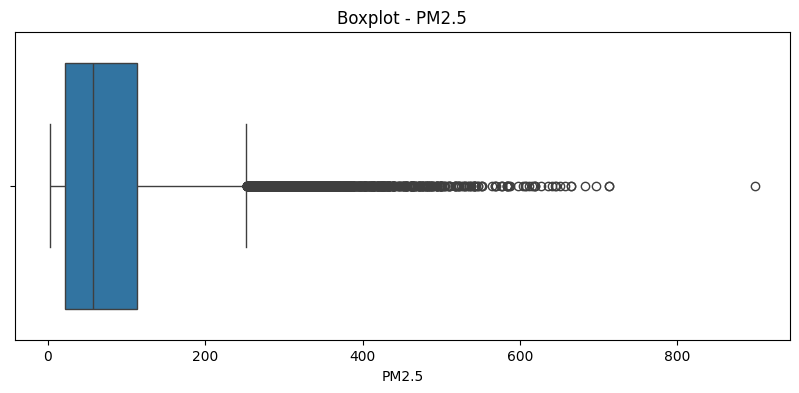

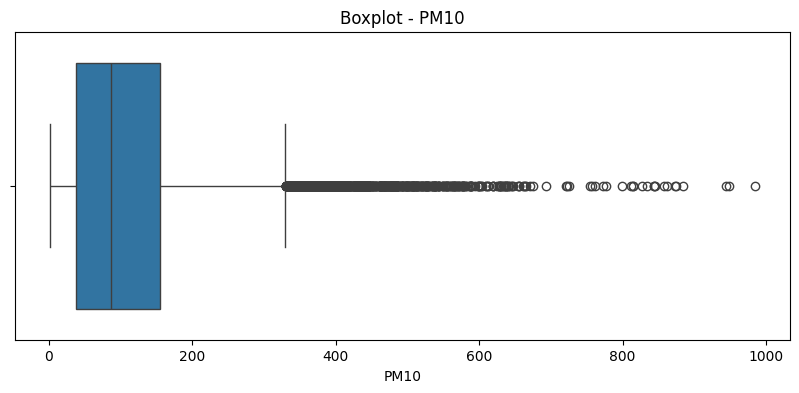

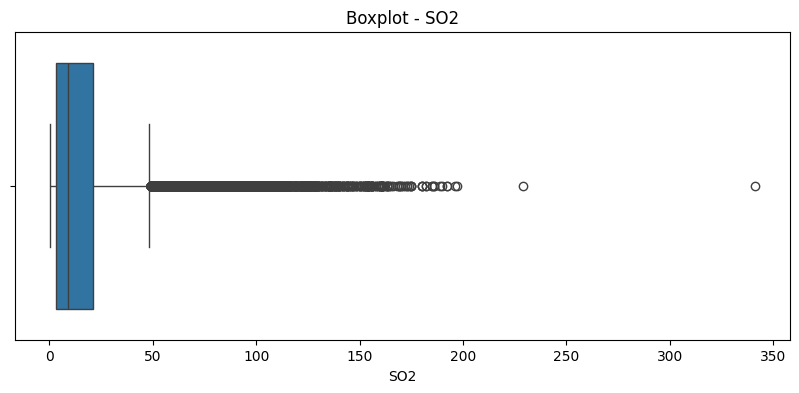

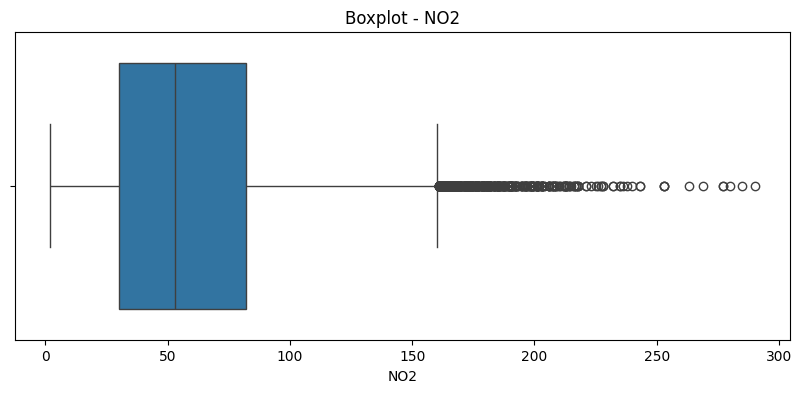

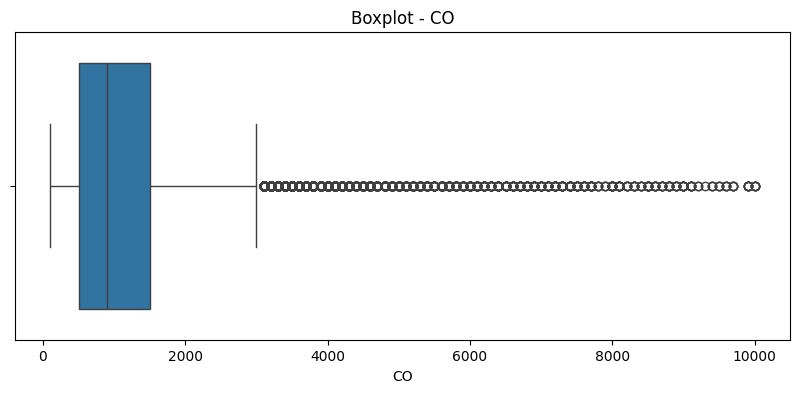

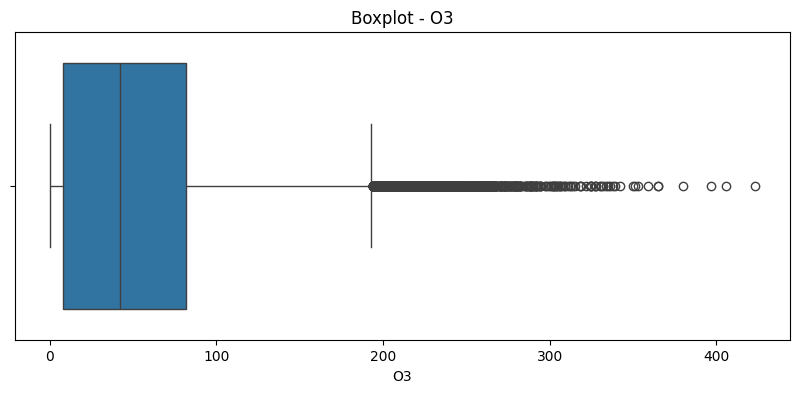

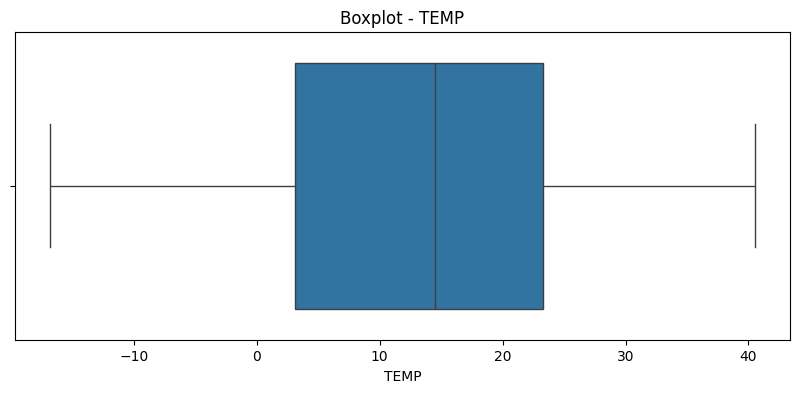

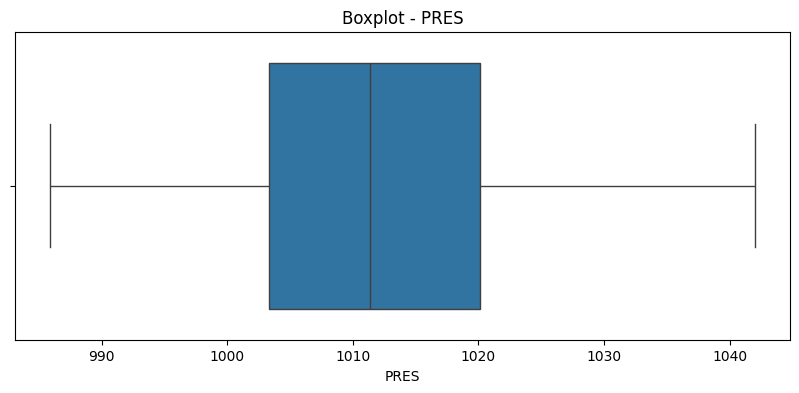

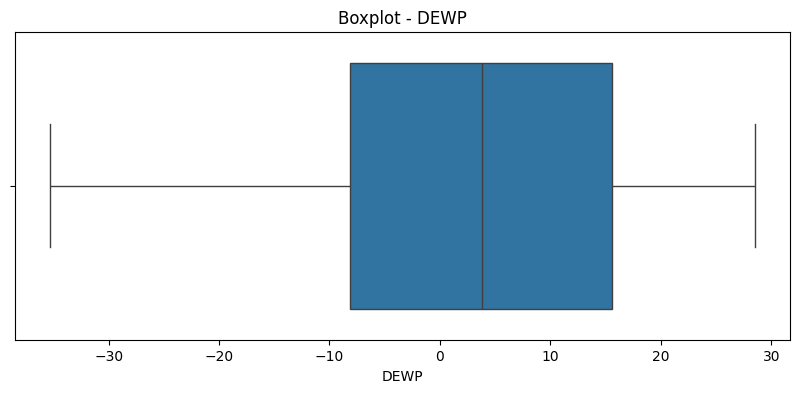

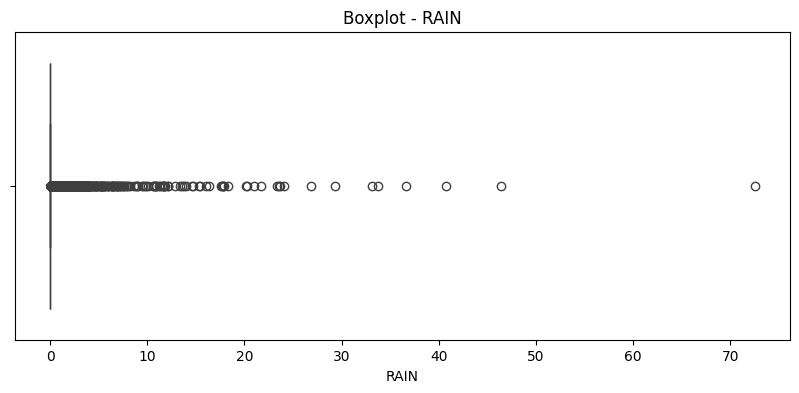

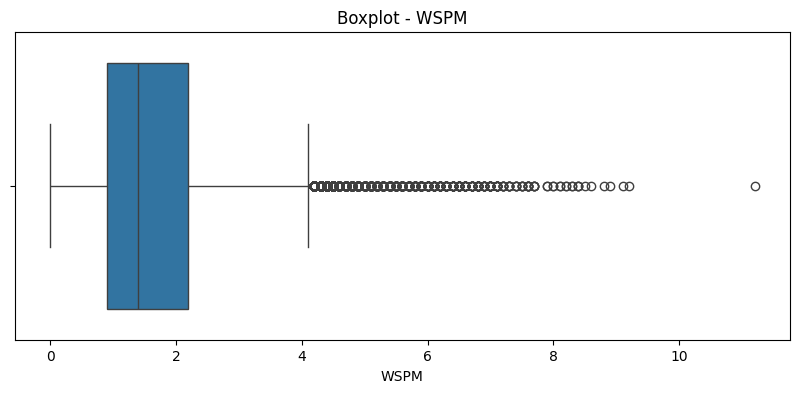

In [ ]:
numeric_cols = [
    "PM2.5", "PM10", "SO2", "NO2",
    "CO", "O3", "TEMP", "PRES",
    "DEWP", "RAIN", "WSPM"
]

for col in numeric_cols:
    plt.figure(figsize=(10, 4))
    sns.boxplot(x=df[col])
    plt.title(f"Boxplot - {col}")
    plt.show()

## 3. Feature Engineering and Preprocessing

This section focuses on preparing the data for the RNN models. It involves setting the `datetime` column as the index, resampling to fill any missing hours, and applying transformations such as spline encoding for cyclical features, standard scaling for numerical features, and one-hot encoding for categorical features.

In [ ]:
# 1. Convert to pandas datetime format
df['datetime'] = pd.to_datetime(df['datetime'])

# 2. Sort chronologically (critical for time series)
df = df.sort_values('datetime').reset_index(drop=True)

# 3. Set datetime as the dataframe index
df.set_index('datetime', inplace=True)

# 4. Check for missing hours (35064 hours is exactly 4 non-leap years + 1 leap day)
# If any rows were missing, this fills them with the last known value
df = df.asfreq('h', method='ffill')

### 3.1. Preprocessing Pipeline for Neural Networks

A `ColumnTransformer` is used to apply different preprocessing steps to different types of features:
- **Cyclical Features (`month`, `day`, `hour`):** Transformed using `SplineTransformer` to capture their cyclical nature.
- **Numeric Features (`PM2.5`, `PM10`, etc.):** Scaled using `StandardScaler` to normalize their ranges.
- **Categorical Features (`wd` - wind direction):** One-hot encoded using `OneHotEncoder`.

The preprocessor is fitted on the training data and then used to transform both training and testing sets.

In [ ]:
# --- 1. DEFINE COLUMN GROUPS ---
# Cyclical features for Spline encoding
cyclical_cols = ['month', 'day', 'hour']

# Numeric features requiring standard scaling
numeric_cols = [
    'PM2.5', 'PM10', 'SO2', 'NO2', 'CO', 'O3',
    'TEMP', 'PRES', 'DEWP', 'RAIN', 'WSPM'
]

# Categorical features requiring encoding (Wind Direction)
categorical_cols = ['wd']

# --- 2. CONSTRUCT THE PREPROCESSOR PIPELINE ---
preprocessor = ColumnTransformer(
    transformers=[
        # Cyclical Processing: periodic splines map 0-23 hours, 1-12 months smoothly
        ('cyclical', SplineTransformer(n_knots=5, degree=3, extrapolation="periodic"), cyclical_cols),

        # Numeric Processing: Standardize to mean=0, variance=1
        ('numeric', StandardScaler(), numeric_cols),

        # Categorical Processing: Convert wind text to numeric fields
        ('categorical', OneHotEncoder(handle_unknown='ignore', sparse_output=False), categorical_cols)
    ],
    # Drop structural identifiers not used as model features
    remainder='drop'
)

# --- 3. EXECUTE PROCESSING ON TRAIN & TEST DATA ---
# (Assumes train_df and test_df have already been split and filled)

# Fit on training data and transform
X_train_processed = preprocessor.fit_transform(train_df)

# Transform test data using the fitted parameters (prevents data leakage)
X_test_processed = preprocessor.transform(test_df)

# --- 4. VERIFY THE SHAPE ---
print("Processed Train Shape:", X_train_processed.shape)
print("Processed Test Shape:", X_test_processed.shape)
print("\nFirst row of fully prepared neural network input matrix:")
print(X_train_processed[0])


Processed Train Shape: (28051, 39)
Processed Test Shape: (7013, 39)

First row of fully prepared neural network input matrix:
[ 0.00338092  0.33007764  0.60242925  0.0641122   0.16666667  0.66666667
  0.16666667  0.          0.16666667  0.66666667  0.16666667  0.
 -0.97692942 -1.15030256 -0.64147477 -1.4577087  -0.79598961  0.4208625
 -1.26072696  1.11480959 -1.58824498 -0.07069681  2.17682505  0.
  0.          0.          0.          0.          0.          1.
  0.          0.          0.          0.          0.          0.
  0.          0.          0.        ]


### 3.2. Creating Time Series Sequences

To prepare the data for recurrent neural networks, sequences are created from the processed features. Each sequence consists of a `lookback_window` (e.g., 24 hours) of features to predict the `PM2.5` value at the next timestep.

In [ ]:
def create_sequences(features, data_df, lookback=24):
    X, y = [], []
    target_values = data_df['PM2.5'].values

    for i in range(len(features) - lookback):
        X.append(features[i : i + lookback])
        y.append(target_values[i + lookback])

    return np.array(X), np.array(y)

# Define your lookback window (e.g., 24 hours of context)
lookback_window = 24

X_train_3d, y_train = create_sequences(X_train_processed, train_df, lookback_window)
X_test_3d, y_test = create_sequences(X_test_processed, test_df, lookback_window)

print("RNN Train Inputs Shape:", X_train_3d.shape)
print("RNN Train Targets Shape:", y_train.shape)


RNN Train Inputs Shape: (28027, 24, 39)
RNN Train Targets Shape: (28027,)


## 4. Model Training and Evaluation

This section defines, compiles, and trains various recurrent neural network (RNN) architectures, including Simple RNN, LSTM, GRU, and their bidirectional variants. Each model's performance is evaluated based on its Mean Absolute Error (MAE) on the validation set.

In [ ]:
rnn_model = Sequential([
    Input(shape=(lookback_window, X_train_3d.shape[2])),
    SimpleRNN(units=64, activation='relu', return_sequences=True),
    SimpleRNN(units=32, activation='relu'),
    Dense(units=1)
])

### 4.1. Deep Simple RNN Model

This is a stacked Simple RNN model with two hidden layers and a dense output layer for regression. The model summary provides an overview of its architecture and parameter count.

In [ ]:
rnn_model.summary()

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_2 (SimpleRNN)        │ (None, 24, 64)         │         6,656 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ simple_rnn_3 (SimpleRNN)        │ (None, 32)             │         3,104 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 9,793 (38.25 KB)

 Trainable params: 9,793 (38.25 KB)

 Non-trainable params: 0 (0.00 B)

The model is compiled with the Adam optimizer, Mean Squared Error (MSE) loss, and Mean Absolute Error (MAE) as a metric.

In [ ]:
rnn_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

The Deep Simple RNN model is trained for 10 epochs with a batch size of 32. The training progress, including loss and MAE for both training and validation sets, is displayed.

In [ ]:
history_rnn = rnn_model.fit(
    X_train_3d, y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_3d, y_test),
    verbose = 1
)

Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 8ms/step - loss: 2083.9382 - mae: 27.7390 - val_loss: 814.6204 - val_mae: 17.2929
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 764.4130 - mae: 16.2396 - val_loss: 509.0677 - val_mae: 13.0613
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 530.8785 - mae: 13.1630 - val_loss: 452.0043 - val_mae: 13.1560
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 446.1285 - mae: 11.9359 - val_loss: 337.6931 - val_mae: 11.3058
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 5s 6ms/step - loss: 427.6149 - mae: 11.6860 - val_loss: 317.1350 - val_mae: 10.4055
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 6ms/step - loss: 400.8680 - mae: 11.2430 - val_loss: 314.8238 - val_mae: 10.3539
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - loss: 394.2180 - mae: 11.1070 - val_loss: 314.4513 - val_mae: 10.3063
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 6s 7ms/step - loss: 384.2964 - mae: 10.8759 - val_loss: 308.3281 - val_mae: 10.1847
Epoch

### 4.2. Deep LSTM Model

This model uses stacked Long Short-Term Memory (LSTM) layers, which are particularly effective for capturing long-term dependencies in sequential data. It has a similar architecture to the Simple RNN but with LSTM units.

In [ ]:
lstm_model = Sequential([
    Input(shape=(lookback_window, X_train_3d.shape[2])),
    LSTM(units=64,return_sequences=True),
    LSTM(units=32),
    Dense(1)
])

lstm_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

history_lstm = lstm_model.fit(
    X_train_3d,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_3d, y_test),
    verbose=1
)

Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - loss: 10653.5957 - mae: 67.6574 - val_loss: 9025.5176 - val_mae: 58.7588
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 8230.7959 - mae: 59.0254 - val_loss: 7603.1597 - val_mae: 56.5390
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 16s 18ms/step - loss: 6764.6997 - mae: 51.1868 - val_loss: 5661.4033 - val_mae: 36.6647
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 15s 11ms/step - loss: 4877.4102 - mae: 34.4190 - val_loss: 4400.3735 - val_mae: 29.6385
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 8s 8ms/step - loss: 3786.1470 - mae: 28.1780 - val_loss: 3543.9985 - val_mae: 26.1084
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 3017.9841 - mae: 24.0430 - val_loss: 2888.3972 - val_mae: 22.2570
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2445.2974 - mae: 20.9465 - val_loss: 2384.1558 - val_mae: 19.7792
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 2011.0953 - mae: 18.6357 - val_loss: 1990.2804 - val

### 4.3. Deep GRU Model

This model utilizes stacked Gated Recurrent Unit (GRU) layers. GRUs are a simpler alternative to LSTMs, offering competitive performance with fewer parameters. The model setup and training process mirror the previous models.

In [ ]:
gru_model = Sequential([
    Input(shape=(lookback_window, X_train_3d.shape[2])),
    GRU(units=64,return_sequences=True),
    GRU(units=32),
    Dense(1)
])

In [ ]:
gru_model.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

In [ ]:
history_gru = gru_model.fit(
    X_train_3d,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_3d, y_test),
    verbose=1
)

Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - loss: 1235.4559 - mae: 14.5479 - val_loss: 1274.1522 - val_mae: 14.5194
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 1065.7405 - mae: 13.6106 - val_loss: 1106.0037 - val_mae: 13.5018
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 932.2652 - mae: 12.8854 - val_loss: 979.6017 - val_mae: 13.1834
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 8s 9ms/step - loss: 827.8632 - mae: 12.3053 - val_loss: 883.3889 - val_mae: 12.7590
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 739.9518 - mae: 11.8131 - val_loss: 786.9930 - val_mae: 12.1652
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 668.7976 - mae: 11.4234 - val_loss: 726.5966 - val_mae: 11.9869
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 7ms/step - loss: 612.9526 - mae: 11.1552 - val_loss: 671.5370 - val_mae: 11.7761
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 7s 8ms/step - loss: 562.8984 - mae: 10.8309 - val_loss: 624.0624 - val_mae: 11.5921
Epo

### 4.4. Bidirectional RNN Model

This model incorporates bidirectional Simple RNN layers, allowing the network to process the sequence in both forward and backward directions. This can help in capturing more comprehensive contextual information.

In [ ]:
print("RNN Best Val MAE:", min(history_rnn.history["val_mae"]))
print("LSTM Best Val MAE:", min(history_lstm.history["val_mae"]))
print("GRU Best Val MAE:", min(history_gru.history["val_mae"]))

RNN Best Val MAE: 10.090336799621582
LSTM Best Val MAE: 15.432921409606934
GRU Best Val MAE: 11.48362922668457


In [ ]:
bidirectional_rnn = Sequential([
    Input(shape=(lookback_window, X_train_3d.shape[2])),
    Bidirectional(SimpleRNN(units=64, activation='relu', return_sequences=True)),
    Bidirectional(SimpleRNN(units=32, activation='relu')),
    Dense(units=1)
])

bidirectional_rnn.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

The model summary provides an overview of its architecture and parameter count.

In [ ]:
bidirectional_rnn.summary()

Model: "sequential_8"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ bidirectional (Bidirectional)   │ (None, 24, 128)        │        13,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ bidirectional_1 (Bidirectional) │ (None, 64)             │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 23,681 (92.50 KB)

 Trainable params: 23,681 (92.50 KB)

 Non-trainable params: 0 (0.00 B)

The Bidirectional RNN model is trained for 10 epochs.

In [ ]:
bidirectional_rnn_history = bidirectional_rnn.fit(
    X_train_3d,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_3d, y_test),
    verbose=1
)

Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 20s 14ms/step - loss: 1108.1969 - mae: 19.1016 - val_loss: 485.7551 - val_mae: 13.8944
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 474.2748 - mae: 12.7635 - val_loss: 421.9237 - val_mae: 12.8182
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 426.9960 - mae: 11.9130 - val_loss: 351.2982 - val_mae: 11.2909
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - loss: 418.3657 - mae: 11.6458 - val_loss: 388.7311 - val_mae: 12.2626
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 396.5026 - mae: 11.3463 - val_loss: 325.1924 - val_mae: 10.5663
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 381.1137 - mae: 11.0388 - val_loss: 571.6717 - val_mae: 14.8953
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 382.8557 - mae: 11.0736 - val_loss: 318.6486 - val_mae: 10.5306
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 9s 10ms/step - loss: 367.8416 - mae: 10.8078 - val_loss: 312.9922 - val_mae: 10.385

### 4.5. Bidirectional LSTM Model

This model combines the power of bidirectional processing with LSTM layers, aiming to leverage both forward and backward contexts with LSTM's ability to handle long-term dependencies.

In [ ]:
bidirectional_lstm = Sequential([
    Input(shape=(lookback_window, X_train_3d.shape[2])),
    Bidirectional(LSTM(units=64,return_sequences=True)),
    Bidirectional(LSTM(units=32)),
    Dense(1)
])

bidirectional_lstm.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)

bidirectional_lstm_history = bidirectional_lstm.fit(
    X_train_3d,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_3d, y_test),
    verbose=1
)



Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 18s 15ms/step - loss: 9259.6338 - mae: 60.9400 - val_loss: 6851.5732 - val_mae: 44.7230
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 5402.6450 - mae: 38.2411 - val_loss: 4404.6626 - val_mae: 30.4373
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 13s 14ms/step - loss: 3525.2544 - mae: 27.3614 - val_loss: 3076.0935 - val_mae: 23.2650
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 2471.8550 - mae: 21.7786 - val_loss: 2253.7544 - val_mae: 19.4066
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 1807.1219 - mae: 17.8540 - val_loss: 1697.8630 - val_mae: 16.3643
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 1383.0946 - mae: 15.6789 - val_loss: 1332.8149 - val_mae: 14.8681
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 1097.1538 - mae: 14.0979 - val_loss: 1079.8629 - val_mae: 13.7349
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 12s 14ms/step - loss: 906.9738 - mae: 13.2257 - val_loss: 879.29

### 4.6. Bidirectional GRU Model

This model uses bidirectional GRU layers, offering a balance between performance and computational efficiency by processing sequences in both directions with GRU units.

In [ ]:
bidirectional_gru = Sequential([
    Input(shape=(lookback_window, X_train_3d.shape[2])),
    Bidirectional(GRU(units=64,return_sequences=True)),
    Bidirectional(GRU(units=32)),
    Dense(1)
])

bidirectional_gru.compile(
    optimizer="adam",
    loss="mse",
    metrics=["mae"]
)
bidirectional_gru_history = bidirectional_gru.fit(
    X_train_3d,
    y_train,
    epochs=10,
    batch_size=32,
    validation_data=(X_test_3d, y_test),
    verbose=1
)

Epoch 1/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 16s 13ms/step - loss: 9023.1240 - mae: 57.9779 - val_loss: 6655.5581 - val_mae: 41.9336
Epoch 2/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 5273.2192 - mae: 36.3692 - val_loss: 4345.1479 - val_mae: 29.5350
Epoch 3/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 3470.4712 - mae: 26.5188 - val_loss: 3043.5330 - val_mae: 22.6957
Epoch 4/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 2445.7224 - mae: 20.9968 - val_loss: 2251.3538 - val_mae: 19.0405
Epoch 5/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 1802.0968 - mae: 17.6345 - val_loss: 1710.8246 - val_mae: 16.6777
Epoch 6/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - loss: 1371.6931 - mae: 15.4483 - val_loss: 1345.4344 - val_mae: 15.0910
Epoch 7/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 13ms/step - loss: 1083.4727 - mae: 13.8570 - val_loss: 1091.5271 - val_mae: 13.9982
Epoch 8/10
876/876 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - loss: 883.0059 - mae: 12.7187 - val_loss: 890.87

## 5. Model Performance Comparison

This section compares the best validation Mean Absolute Error (MAE) achieved by each trained model to determine which architecture performs best on the given task.

In [ ]:
print("RNN Best Val MAE:", min(bidirectional_rnn_history.history["val_mae"]))
print("LSTM Best Val MAE:", min(bidirectional_lstm_history.history["val_mae"]))
print("GRU Best Val MAE:", min(bidirectional_gru_history.history["val_mae"]))

RNN Best Val MAE: 10.319869995117188
LSTM Best Val MAE: 11.809001922607422
GRU Best Val MAE: 12.059887886047363


### 5.1. Summary of Results

The table below presents the best validation MAE for each model, sorted from lowest to highest. This allows for a quick comparison of their predictive accuracy.

In [ ]:
results = {
    "Deep RNN": min(history_rnn.history["val_mae"]),
    "Deep LSTM": min(history_lstm.history["val_mae"]),
    "Deep GRU": min(history_gru.history["val_mae"]),
    "Bi-RNN": min(bidirectional_rnn_history.history["val_mae"]),
    "Bi-LSTM": min(bidirectional_lstm_history.history["val_mae"]),
    "Bi-GRU": min(bidirectional_gru_history.history["val_mae"])
}

results

{'Deep RNN': 10.090336799621582,
 'Deep LSTM': 15.432921409606934,
 'Deep GRU': 11.48362922668457,
 'Bi-RNN': 10.319869995117188,
 'Bi-LSTM': 11.809001922607422,
 'Bi-GRU': 12.059887886047363}

In [ ]:
results_df = pd.DataFrame(
    list(results.items()),
    columns=["Model", "Best Validation MAE"]
).sort_values("Best Validation MAE")

results_df

,Model,Best Validation MAE
0,Deep RNN,10.090337
3,Bi-RNN,10.319870
2,Deep GRU,11.483629
4,Bi-LSTM,11.809002
5,Bi-GRU,12.059888
1,Deep LSTM,15.432921


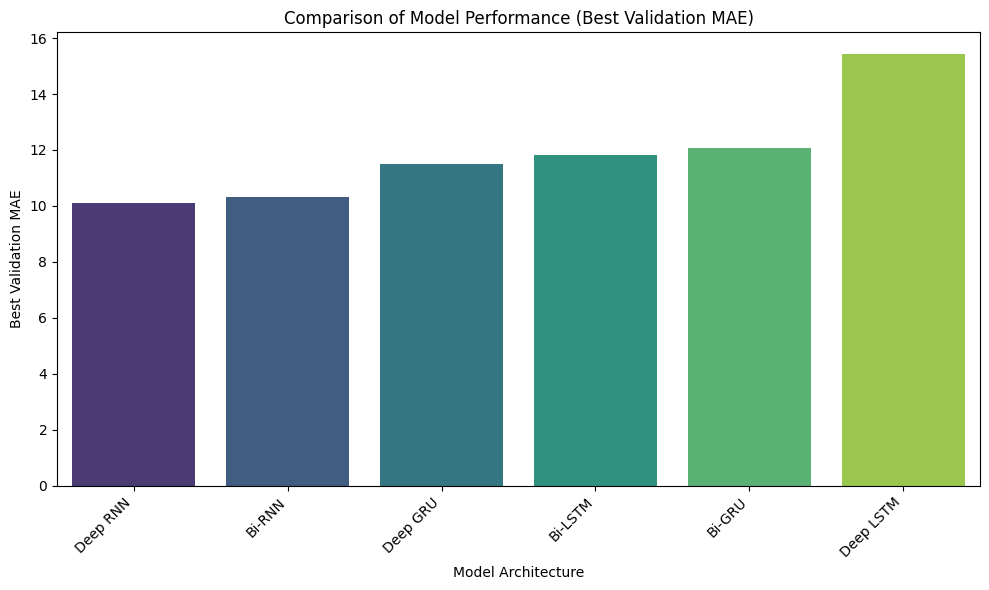

In [ ]:
plt.figure(figsize=(10, 6))
sns.barplot(x='Model', y='Best Validation MAE', data=results_df, hue='Model', palette='viridis', legend=False)
plt.title('Comparison of Model Performance (Best Validation MAE)')
plt.xlabel('Model Architecture')
plt.ylabel('Best Validation MAE')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

### 5.2. Detailed Training Metrics Summary

The following table summarizes the final epoch performance (Loss and MAE) for both training and validation sets across all tested architectures.

In [ ]:
metrics_summary = []

models_histories = [
    ("Deep RNN", history_rnn),
    ("Deep LSTM", history_lstm),
    ("Deep GRU", history_gru),
    ("Bi-RNN", bidirectional_rnn_history),
    ("Bi-LSTM", bidirectional_lstm_history),
    ("Bi-GRU", bidirectional_gru_history)
]

for name, history in models_histories:
    metrics_summary.append({
        "Model": name,
        "Train Loss (MSE)": history.history['loss'][-1],
        "Train MAE": history.history['mae'][-1],
        "Val Loss (MSE)": history.history['val_loss'][-1],
        "Val MAE": history.history['val_mae'][-1]
    })

summary_df = pd.DataFrame(metrics_summary)
display(summary_df.sort_values("Val MAE"))

,Model,Train Loss (MSE),Train MAE,Val Loss (MSE),Val MAE
0,Deep RNN,368.665039,10.733146,301.651276,10.090337
3,Bi-RNN,366.129547,10.802048,347.534149,11.195534
2,Deep GRU,494.673737,10.471855,572.226074,11.483629
4,Bi-LSTM,670.825256,11.869603,654.853821,11.809002
5,Bi-GRU,635.205566,11.385538,672.390137,12.478559
1,Deep LSTM,1408.441406,15.474532,1440.968384,15.432921


## 6. Discussion: RNN vs. LSTM Performance

Based on the results, we observed that the **Deep RNN** and **Bi-RNN** models achieved lower validation MAE (approx. 10.09) compared to the **LSTM** models (approx. 11.8 - 15.4).

### 6.1. Theoretical Comparison

*   **Simple RNN (Recurrent Neural Networks):**
    *   **Architecture:** Uses a basic feedback loop where the output of a hidden state is fed back as input for the next step.
    *   **Short-term Memory:** Good at capturing relationships within a short window of time.
    *   **Limitation:** Suffers from the **vanishing gradient problem**, making it difficult to learn dependencies over long sequences.

*   **LSTM (Long Short-Term Memory):**
    *   **Architecture:** Introduces a 'Cell State' and three 'Gates' (Input, Forget, and Output).
    *   **Long-term Memory:** Specifically designed to mitigate the vanishing gradient problem, allowing the network to decide what information to keep or discard over long periods.

### 6.2. Why did the Simple RNN perform better here?

In many air quality datasets, immediate past observations (like the last few hours) are highly predictive of the next hour. Because our `lookback_window` was set to 24 hours, the **Simple RNN** was likely sufficient to capture these short-term hourly dependencies without the added complexity of the LSTM gating mechanisms. LSTMs often require more data and more epochs to converge efficiently, which explains the higher MAE observed in this specific 10-epoch training run.